Import packages

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

In [3]:
from pathlib import Path
import plotly
import plotly.express as px
import scipy.stats

os.environ["OMP_NUM_THREADS"] = "1"  # because of a data leak of KMeans on windows
import fba_comparison_stats as cmp
from efflux_method import *
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

Import the models

How to make each models, how to put information in it? Efflux?

In [4]:
M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")

In [230]:
#Add importation constraints
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0

In [231]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


In [232]:
list_of_genes = []
for i in M_xanthus.genes:
    list_of_genes.append(i.id)

In [233]:
# Getting fluxes with constrains
dico = {
    14: "Alone",
    2: "P_E_coli_1-3",
    5: "P_B_subtilis",
    8: "P_Caulobacter",
    20: "P_E_coli_1-1",
}
for i in [14, 2, 5, 8, 20]:
    M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")
    #Add importation constraints
    M_xanthus.reactions.EX_alaala_e.lower_bound = 0
    M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
    M_xanthus.reactions.EX_his_L_e.lower_bound = 0
    M_xanthus.reactions.EX_co2_e.lower_bound = 0
    M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
    M_xanthus.reactions.EX_malt_e.lower_bound = 0
    M_xanthus.reactions.EX_met_L_e.lower_bound = 0
    M_xanthus.reactions.EX_pheme_e.lower_bound = 0
    M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
    M_xanthus.reactions.EX_orn_e.lower_bound = 0
    M_xanthus.reactions.EX_ac_e.lower_bound = 0
    M_xanthus.reactions.EX_fru_e.lower_bound = 0
    M_xanthus.reactions.EX_for_e.lower_bound = 0
    M_xanthus.reactions.EX_gam_e.lower_bound = 0
    DictAP = read_csv_data(
        "/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_iMAT.csv",
        id_gene=1,
        id_val=i,
        list_of_genes=list_of_genes,
        head=True,
        quantile=0.95,
    )
    Eflux(M_xanthus, DictAP, const=100, default_exp_val=1, ignore_human=True)
    M_xanthus.reactions.EX_glc_D_e.bounds = (0, 1000)
    model_c = M_xanthus.copy()
    write_sbml_model(
        model_c,
        "/home/mickael/github/M_xanthus-E_coli-Predation/fba_comparer-main/Models_Preda/M_xanthus_V4_efflux_"
        + dico[i]
        + ".xml",
    )
    print(dico[i] + " Done!")

Alone Done!
P_E_coli_1-3 Done!
P_B_subtilis Done!
P_Caulobacter Done!
P_E_coli_1-1 Done!


In [234]:
M_xanthus_alone = read_sbml_model("Models_Preda/M_xanthus_V4_efflux_Alone.xml")
solution_alone = M_xanthus_alone.optimize()

In [235]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-3.xml"
)
solution_predation_E_3 = M_xanthus_predation.optimize()

In [236]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_B_subtilis.xml"
)
solution_predation_B = M_xanthus_predation.optimize()

In [237]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_Caulobacter.xml"
)
solution_predation_C = M_xanthus_predation.optimize()

In [238]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-1.xml"
)
solution_predation_E_1 = M_xanthus_predation.optimize()

In [239]:
print(f"Alone:\t{solution_alone.objective_value}")
print(f"Predation E.coli 1/1 :\t{solution_predation_E_1.objective_value}")
print(f"Predation E.coli 1/3 :\t{solution_predation_E_3.objective_value}")
print(f"Predation B_subtilis:\t{solution_predation_B.objective_value}")
print(f"Predation Caulobacter:\t{solution_predation_C.objective_value}")

Alone:	0.20445275853613387
Predation E.coli 1/1 :	0.16754778715563906
Predation E.coli 1/3 :	0.10165517381424193
Predation B_subtilis:	0.15158979104534823
Predation Caulobacter:	0.16752521568295684


## **FBA Comparer**
**Create combined dataframe and preprocess data**

Filter all reactions where fluxes are zero:

In [240]:
solutions = [
    solution_alone,
    solution_predation_E_1,
    solution_predation_E_3,
    solution_predation_B,
    solution_predation_C,
]
conditions = [
    "Alone",
    "Predation E.coli 1/1",
    "Predation E.coli 1/3",
    "Predation B. subtilis",
    "Predation Caulobacter",
]
obj_values = [
    solution_alone.objective_value,
    solution_predation_E_1.objective_value,
    solution_predation_E_3.objective_value,
    solution_predation_B.objective_value,
    solution_predation_C.objective_value,
]

mxanthus = cmp.build_dataframe(M_xanthus_alone, solutions, conditions)
mxanthus_filtered = cmp.filter_dataframe(mxanthus, conditions, rounding=True)
print(f"Number of reactions in the models: {len(mxanthus)}")
print(f"Number of nonzero reactions in the models: {len(mxanthus_filtered)}")

Number of reactions in the models: 1339
Number of nonzero reactions in the models: 476


normalize data:

In [241]:
mxanthus_normalized = cmp.normalize_dataframe_cols(
    mxanthus_filtered, conditions, obj_values
)  # biomass normalization
mxanthus_normalized_div_by_max = cmp.normalize_dataframe_rows(
    mxanthus_normalized, conditions, "div_by_max"
)  # normalization reactions
# note: there is no difference between the order of div_by_max normalization and filtering for changing reactions
mxanthus_normalized_div_by_max_changing = mxanthus_normalized_div_by_max[
    mxanthus_normalized_div_by_max["Std_dev"] >= 0.01
]  # keep only reactions that change
print(
    f"Number of normalized changing reactions: {len(mxanthus_normalized_div_by_max_changing)}"
)

Number of normalized changing reactions: 181


## Identify reactions with most/least variation

Most affected / change reaction

In [307]:
M_xanthus.reactions.rxn01444_c

Reaction identifier,rxn01444_c
Name,ATP:deoxyguanosine 5'-phosphotransferase [c]
Memory address,0x7d976c37b200
Stoichiometry,atp_c + dgsn_c <=> adp_c + dgmp_c + h_c ATP [c] + Deoxyguanosine [c] <=> ADP [c] + dGMP [c] + H+ [c]
GPR,(MXAN_3331 and MXAN_2054 and MXAN_2591) or (MXAN_3331 and MXAN_2054 and MXAN_2591)
Lower bound,-17.21363414645268
Upper bound,17.21363414645268


In [305]:
most_variable_bar_plot = cmp.bar_plot_flux_variation(
    mxanthus_normalized, conditions, 0, 10
)
most_variable_bar_plot.show()

In [281]:
sorted_flux = mxanthus_normalized[["ID", "Name", "Std_dev"]].sort_values(
    by=["Std_dev"], ascending=False
)
sorted_flux["Kegg"] = [
    M_xanthus_alone.reactions.get_by_id(id).__dict__["_annotation"].get("kegg.reaction")
    for id in sorted_flux["ID"]
]
sorted_flux[0:20]

,ID,Name,Std_dev,Kegg
583,rxn01508_c,ATP:deoxyadenosine 5'-phosphotransferase [c],11.477667,R02089
842,rxn01507_c,2'-Deoxyadenosine 5'-monophosphate phosphohydr...,11.477667,R02088
1261,EX_pi_e,Exchange for Phosphate [e],7.870547,None
672,rxn05312_c,Inorganic phosphate transporter [c],7.870547,None
342,rxn01444_c,ATP:deoxyguanosine 5'-phosphotransferase [c],7.108060,R01967
217,rxn01445_c,2'-Deoxyguanosine 5'-monophosphate phosphohydr...,6.916942,R01968
1289,EX_h_e,Exchange for H+ [e],4.011815,None
81,rxn11268_c,phosphate ABC transporter permease protein [c],3.715915,None
1255,EX_ppi_e,Exchange for PPi [e],3.715915,None
453,rxn09176_c,polyphosphate kinase [c],3.554398,None


In [244]:
from bioservices import KEGG

k = KEGG()

for rxn in M_xanthus.reactions:
    if "kegg.reaction" in rxn.annotation:
        kegg_id = rxn.annotation["kegg.reaction"]
        try:
            data = k.get(kegg_id)
            parsed = k.parse(data)
            if "PATHWAY" in parsed:
                rxn.subsystem = list(parsed["PATHWAY"].values())[0]
        except:
            continue

WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02371)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R01549)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02097)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02292)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00962)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00967)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https

**LOOKING STUFF**

In [245]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
417,rxn01100_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,0.611333,R01512
531,rxn01106_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",0.611333,R01518
700,rxn00459_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,0.611333,R00658
157,rxn00781_c,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,0.611333,R01061
298,rxn00747_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,0.610266,R01015
216,rxn00305_c,GTP:oxaloacetate carboxy-lyase (adding GTP;pho...,0.381784,R00431
331,rxn00147_c,"ATP:pyruvate,water phosphotransferase [c]",0.290446,R00199
414,rxn00786_c,"D-fructose-1,6-bisphosphate D-glyceraldehyde-3...",0.000477,R01068
203,rxn00549_c,"D-Fructose-1,6-bisphosphate 1-phosphohydrolase...",0.000477,R00762


Pathway analysis

In [246]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)] #Glycolysis / Gluconeogenesis

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
157,rxn00781_c,rxn00781_c: g3p_c + nad_c + pi_c <=> 13dpg_c +...,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,1.442351,0.407871,2.123662,1.285330,1.279504,0.611333,1.307744
203,rxn00549_c,rxn00549_c: fdp_c + h2o_c --> f6p_c + pi_c,"D-Fructose-1,6-bisphosphate 1-phosphohydrolase...",0.652612,0.652612,0.651545,0.652612,0.652612,0.000477,0.652399
216,rxn00305_c,rxn00305_c: gtp_c + oaa_c <=> co2_c + gdp_c + ...,GTP:oxaloacetate carboxy-lyase (adding GTP;pho...,-1.091427,-0.339255,-1.379600,-0.851830,-0.942533,0.381784,-0.920929
298,rxn00747_c,rxn00747_c: g3p_c <=> dhap_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,-2.475137,-1.440657,-3.153248,-2.318117,-2.312290,0.610266,-2.339890
331,rxn00147_c,rxn00147_c: atp_c + h2o_c + pyr_c --> amp_c + ...,"ATP:pyruvate,water phosphotransferase [c]",0.000000,0.681846,0.000000,0.316961,0.413491,0.290446,0.282459
414,rxn00786_c,rxn00786_c: fdp_c <=> dhap_c + g3p_c,"D-fructose-1,6-bisphosphate D-glyceraldehyde-3...",-0.652612,-0.652612,-0.651545,-0.652612,-0.652612,0.000477,-0.652399
417,rxn01100_c,rxn01100_c: 3pg_c + atp_c <=> 13dpg_c + adp_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,-1.442351,-0.407871,-2.123662,-1.285330,-1.279504,0.611333,-1.307744
531,rxn01106_c,rxn01106_c: 2pg_c <=> 3pg_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",-1.442351,-0.407871,-2.123662,-1.285330,-1.279504,0.611333,-1.307744
700,rxn00459_c,rxn00459_c: 2pg_c <=> h2o_c + pep_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,1.442351,0.407871,2.123662,1.285330,1.279504,0.611333,1.307744


In [247]:
M_xanthus_alone.reactions.rxn00459_c.flux

0.29489263068798427

In [309]:
M_xanthus_alone.metabolites.damp_c.summary()

Percent,Flux,Reaction,Definition
100.00%,7.595,rxn01507_c,damp_c + h2o_c <=> dad_2_c + pi_c
Percent,Flux,Reaction,Definition
100.00%,-7.595,rxn01508_c,atp_c + dad_2_c <=> adp_c + damp_c + h_c


In [249]:
M_xanthus_alone.metabolites.dgdp_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.001285,rxn05233_c,gdp_c + trdrd_c --> dgdp_c + h2o_c + trdox_c
Percent,Flux,Reaction,Definition
100.00%,-0.001285,rxn01510_c,cytd_c + dgtp_c <=> cmp_c + dgdp_c + h_c


In [250]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Citrate cycle (TCA cycle)":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
653,rxn00799_c,(S)-malate hydro-lyase (fumarate-forming) [c],1.720530,R01082
287,rxn00248_c,(S)-malate:NAD+ oxidoreductase [c],1.592569,R00342
846,rxn01388_c,isocitrate hydro-lyase (cis-aconitate-forming)...,0.311946,R01900
919,rxn00974_c,citrate hydro-lyase (cis-aconitate-forming) [c],0.311946,R01325
961,rxn00256_c,acetyl-CoA:oxaloacetate C-acetyltransferase (t...,0.311946,R00351
176,rxn00250_c,Pyruvate:carbon-dioxide ligase (ADP-forming) [c],0.210376,R00344
26,rxn00199_c,oxalosuccinate carboxy-lyase (2-oxoglutarate-f...,0.175148,R00268
734,rxn01387_c,Isocitrate:NADP+ oxidoreductase [c],0.175148,R01899
121,rxn02376_c,R03316 [c],0.166259,R03316
987,rxn00441_c,R00621 [c],0.166259,R00621


In [251]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)] #TCA Cycle

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
26,rxn00199_c,rxn00199_c: h_c + oxasucc_c --> akg_c + co2_c,oxalosuccinate carboxy-lyase (2-oxoglutarate-f...,0.805174,0.449559,0.907832,0.631767,0.661793,0.175148,0.691225
121,rxn02376_c,rxn02376_c: 3_Carboxy_1_hydroxypropyl_ThPP_c +...,R03316 [c],-0.292085,-0.458273,0.000000,-0.276065,-0.311550,0.166259,-0.267595
176,rxn00250_c,rxn00250_c: atp_c + hco3_c + pyr_c <=> adp_c +...,Pyruvate:carbon-dioxide ligase (ADP-forming) [c],0.801521,1.288228,1.052975,0.883548,0.787568,0.210376,0.962768
284,rxn01872_c,rxn01872_c: dhlam_c + succoa_c <=> coa_c + sdh...,succinyl-CoA:enzyme N6-(dihydrolipoyl)lysine S...,0.292085,0.458273,0.000000,0.276065,0.311550,0.166259,0.267595
287,rxn00248_c,rxn00248_c: mal_L_c + nad_c <=> h_c + nadh_c +...,(S)-malate:NAD+ oxidoreductase [c],-5.856650,-2.975149,-6.751456,-5.185097,-3.475635,1.592569,-4.848797
653,rxn00799_c,rxn00799_c: mal_L_c <=> fum_c + h2o_c,(S)-malate hydro-lyase (fumarate-forming) [c],5.856650,2.975149,6.751456,5.141747,2.931045,1.720530,4.731209
734,rxn01387_c,rxn01387_c: icit_c + nadp_c <=> h_c + nadph_c ...,Isocitrate:NADP+ oxidoreductase [c],0.805174,0.449559,0.907832,0.631767,0.661793,0.175148,0.691225
846,rxn01388_c,rxn01388_c: icit_c <=> acon_C_c + h2o_c,isocitrate hydro-lyase (cis-aconitate-forming)...,-0.800374,-0.444759,-0.903032,-0.583617,-0.112402,0.311946,-0.568837
919,rxn00974_c,rxn00974_c: cit_c <=> acon_C_c + h2o_c,citrate hydro-lyase (cis-aconitate-forming) [c],0.800374,0.444759,0.903032,0.583617,0.112402,0.311946,0.568837
961,rxn00256_c,rxn00256_c: cit_c + coa_c + h_c <=> accoa_c + ...,acetyl-CoA:oxaloacetate C-acetyltransferase (t...,-0.800374,-0.444759,-0.903032,-0.583617,-0.112402,0.311946,-0.568837


In [7]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Pyrimidine metabolism":
        liste.append(i)

filter = sorted_flux.loc[sorted_flux["ID"].isin(liste)][0:3]["ID"]
sorted_flux.loc[sorted_flux["ID"].isin(liste)]

NameError: name 'sorted_flux' is not defined

In [313]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(filter)] #Pyrimidine

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
375,rxn01518_c,rxn01518_c: atp_c + duri_c --> adp_c + dump_c ...,ATP:deoxyuridine 5'-phosphotransferase [c],3.208497,3.123597,4.497049,4.238693,3.815452,0.608942,3.776658
499,rxn00711_c,rxn00711_c: h_c + ppi_c + ump_c <=> prpp_c + u...,UMP:diphosphate phospho-alpha-D-ribosyltransfe...,-7.908445,-5.083840,-9.793115,-7.497406,-1.602268,3.152015,-6.377015
716,rxn01366_c,rxn01366_c: pi_c + uri_c <=> r1p_c + ura_c,Uridine:phosphate alpha-D-ribosyltransferase [c],11.116942,8.207437,14.290165,11.736099,5.417720,3.419050,10.153673
749,rxn01517_c,rxn01517_c: atp_c + dump_c <=> adp_c + dudp_c,ATP:dUMP phosphotransferase [c],3.202211,3.117311,4.490763,4.232407,3.809166,0.608942,3.770372
762,rxn01512_c,rxn01512_c: atp_c + dtdp_c <=> adp_c + dttp_c,ATP:dTDP phosphotransferase [c],0.000000,0.000000,0.000000,0.000000,-2.128469,0.951880,-0.425694
909,rxn00119_c,rxn00119_c: atp_c + ump_c <=> adp_c + udp_c,ATP:UMP phosphotransferase [c],-3.055390,-2.970491,-4.343943,-4.085586,-3.662346,0.608942,-3.623551
910,rxn00709_c,rxn00709_c: atp_c + uri_c <=> adp_c + h_c + ump_c,ATP:uridine 5'-phosphotransferase [c],-11.199767,-8.290262,-14.372989,-11.818924,-5.500545,3.419050,-10.236497
977,rxn01799_c,rxn01799_c: duri_c + pi_c <=> 2dr1p_c + ura_c,deoxyuridine:orthophosphate 2-deoxy-D-ribosylt...,-3.208497,-3.123597,-4.497049,-4.238693,-3.815452,0.608942,-3.776658
1025,rxn01513_c,rxn01513_c: atp_c + dtmp_c + h_c <=> adp_c + d...,ATP:dTMP phosphotransferase [c],-0.001600,-0.001600,-0.001600,-0.001600,-2.130069,0.951880,-0.427294
1061,rxn06075_c,rxn06075_c: dudp_c + h2o_c + trdox_c <=> trdrd...,2'-Deoxyuridine 5'-diphosphate:oxidized-thiore...,3.202211,3.117311,4.490763,4.232407,3.809166,0.608942,3.770372


In [6]:
M_xanthus.reactions.rxn00711_c

Reaction identifier,rxn00711_c
Name,UMP:diphosphate phospho-alpha-D-ribosyltransferase [c]
Memory address,0x7ee0ec2f1580
Stoichiometry,h_c + ppi_c + ump_c <=> prpp_c + ura_c H+ [c] + PPi [c] + UMP [c] <=> PRPP [c] + Uracil [c]
GPR,MXAN_0124
Lower bound,-1000.0
Upper bound,1000.0


In [346]:
M_xanthus.metabolites.get_by_id("pep_c").summary()

Percent,Flux,Reaction,Definition
13.32%,0.01888,rxn00304_c,gtp_c + pyr_c --> gdp_c + h_c + pep_c
86.68%,0.1228,rxn00460_c,pyr_c + utp_c --> h_c + pep_c + udp_c
Percent,Flux,Reaction,Definition
12.77%,-0.01809,rxn00305_c,gtp_c + oaa_c <=> co2_c + gdp_c + pep_c
3.79%,-0.005375,rxn00461_c,pep_c + uacgam_c --> pi_c + uaccg_c
37.93%,-0.05374,rxn01332_c,e4p_c + h2o_c + pep_c --> 2dda7p_c + pi_c
7.59%,-0.01075,rxn02331_c,kdo8p_c + pi_c <=> ara5p_c + h2o_c + pep_c
37.93%,-0.05374,rxn02476_c,pep_c + skm5p_c <=> 3psme_c + pi_c


**Pathway analysis**

In [347]:
M_xanthus.metabolites.uacgam_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.0215,rxn00293_c,acgam1p_c + h_c + utp_c --> ppi_c + uacgam_c
Percent,Flux,Reaction,Definition
25.00%,-0.005375,rxn00461_c,pep_c + uacgam_c --> pi_c + uaccg_c
25.00%,-0.005375,rxn03408_c,uacgam_c + uagmda_c <=> h_c + uaagmda_c + udp_c
50.00%,-0.01075,rxn06729_c,3htdACP_c + uacgam_c <=> ACP_c + u3aga_c


In [254]:
pathway_dict_M = {}
for i in M_xanthus.reactions:
    if i.subsystem in pathway_dict_M:
        pathway_dict_M[i.subsystem].append(i.id)
    else:
        pathway_dict_M[i.subsystem] = [i.id]

In [283]:
pw_list = cmp.pathway_variability(
    mxanthus_normalized, pathway_dict_M, ascending=True, num=20
)

Purine metabolism		 -> 1.63 (contains 36 reactions)
Pyrimidine metabolism		 -> 0.74 (contains 21 reactions)
Glycerophospholipid metabolism		 -> 0.61 (contains 1 reactions)
Citrate cycle (TCA cycle)		 -> 0.48 (contains 11 reactions)
Glycolysis / Gluconeogenesis		 -> 0.41 (contains 9 reactions)
		 -> 0.34 (contains 149 reactions)
Glyoxylate and dicarboxylate metabolism		 -> 0.33 (contains 3 reactions)
Alanine, aspartate and glutamate metabolism		 -> 0.27 (contains 7 reactions)
Pyruvate metabolism		 -> 0.24 (contains 1 reactions)
Arginine biosynthesis		 -> 0.22 (contains 7 reactions)
Carbapenem biosynthesis		 -> 0.16 (contains 1 reactions)
Fatty acid biosynthesis		 -> 0.12 (contains 28 reactions)
Valine, leucine and isoleucine degradation		 -> 0.12 (contains 4 reactions)
Fatty acid elongation		 -> 0.10 (contains 18 reactions)
Glycine, serine and threonine metabolism		 -> 0.09 (contains 12 reactions)
Arginine and proline metabolism		 -> 0.06 (contains 5 reactions)
Benzoate degradation		 ->

In [284]:
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        print(i)

rxn02342_c
rxn00172_c
rxn00545_c
rxn00148_c
rxn00781_c
rxn00549_c
rxn00506_c
rxn00305_c
rxn00747_c
rxn00147_c
rxn01871_c
rxn00786_c
rxn01100_c
rxn01106_c
rxn00543_c
rxn00011_c
rxn00459_c
rxn00175_c
rxn01171_c
rxn15249_c
rxn20583_c


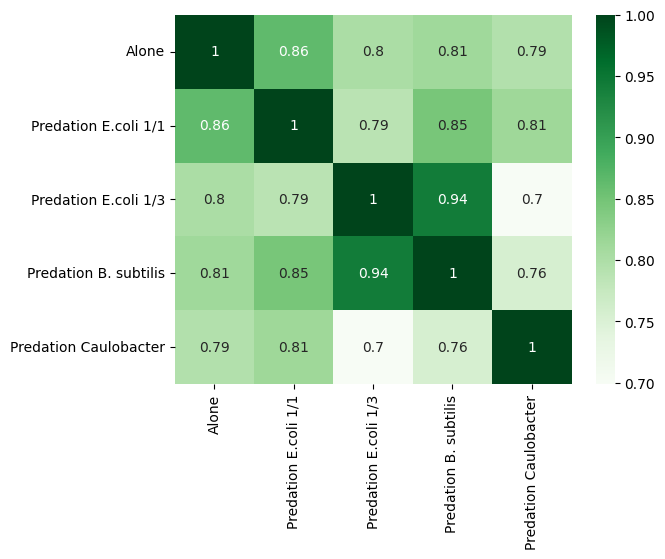

In [285]:
fig_r = cmp.correlation_matrix(
    mxanthus_normalized_div_by_max_changing, conditions, color="Greens"
)

## Flux correlation network

In [286]:
import seaborn as sns
import matplotlib.pyplot as plt

In [287]:
corr_matrix = cmp.flux_coupling_matrix(
    mxanthus_normalized_div_by_max, conditions, remove_unchanging=0.01, abs_values=True
)

295 reaction were removed, because their Std_dev is lower than 0.01
The following 1 reactions were removed because they swap signs across conditions: ['rxn00165_c']


In [288]:
mask = []
for i in corr_matrix:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        mask.append(i)

new = corr_matrix.filter(mask, axis=0)
corr_matrix_filter = new.filter(mask, axis=1)

corr_matrix_filter

,rxn00836_c,rxn01358_c,rxn00800_c,rxn00913_c,rxn01445_c,rxn00917_c,rxn01444_c,rxn00237_c,rxn00132_c,rxn00838_c,rxn00831_c,rxn01509_c,rxn01548_c,rxn01544_c,rxn01508_c,rxn01507_c,rxn01446_c,rxn05233_c,rxn01225_c,rxn01137_c
rxn00836_c,1.000000,1.000000,0.933957,0.576881,-0.723177,0.770217,-0.675202,0.893308,0.934244,0.933957,-0.826699,0.333026,0.576881,0.770217,-0.099958,-0.099958,0.333026,0.333026,0.770217,0.933957
rxn01358_c,1.000000,1.000000,0.933957,0.576881,-0.723177,0.770217,-0.675202,0.893308,0.934244,0.933957,-0.826699,0.333026,0.576881,0.770217,-0.099958,-0.099958,0.333026,0.333026,0.770217,0.933957
rxn00800_c,0.933957,0.933957,1.000000,0.625589,-0.523138,0.603024,-0.465507,0.994922,0.999999,1.000000,-0.571020,0.508529,0.625589,0.603024,-0.381140,-0.381140,0.508529,0.508529,0.603024,1.000000
rxn00913_c,0.576881,0.576881,0.625589,1.000000,-0.037657,0.792119,0.042336,0.621224,0.624866,0.625589,-0.340244,0.921922,1.000000,0.792119,-0.612185,-0.612185,0.921922,0.921922,0.792119,0.625589
rxn01445_c,-0.723177,-0.723177,-0.523138,-0.037657,1.000000,-0.516525,0.996600,-0.454204,-0.524423,-0.523138,0.837586,0.274171,-0.037657,-0.516525,-0.582327,-0.582327,0.274171,0.274171,-0.516525,-0.523138
rxn00917_c,0.770217,0.770217,0.603024,0.792119,-0.516525,1.000000,-0.460331,0.539317,0.603033,0.603024,-0.819873,0.493830,0.792119,1.000000,-0.054079,-0.054079,0.493830,0.493830,1.000000,0.603024
rxn01444_c,-0.675202,-0.675202,-0.465507,0.042336,0.996600,-0.460331,1.000000,-0.395495,-0.466846,-0.465507,0.818116,0.352468,0.042336,-0.460331,-0.638445,-0.638445,0.352468,0.352468,-0.460331,-0.465507
rxn00237_c,0.893308,0.893308,0.994922,0.621224,-0.454204,0.539317,-0.395495,1.000000,0.994838,0.994922,-0.485643,0.542742,0.621224,0.539317,-0.450829,-0.450829,0.542742,0.542742,0.539317,0.994922
rxn00132_c,0.934244,0.934244,0.999999,0.624866,-0.524423,0.603033,-0.466846,0.994838,1.000000,0.999999,-0.571683,0.507493,0.624866,0.603033,-0.379765,-0.379765,0.507493,0.507493,0.603033,0.999999
rxn00838_c,0.933957,0.933957,1.000000,0.625589,-0.523138,0.603024,-0.465507,0.994922,0.999999,1.000000,-0.571020,0.508529,0.625589,0.603024,-0.381140,-0.381140,0.508529,0.508529,0.603024,1.000000


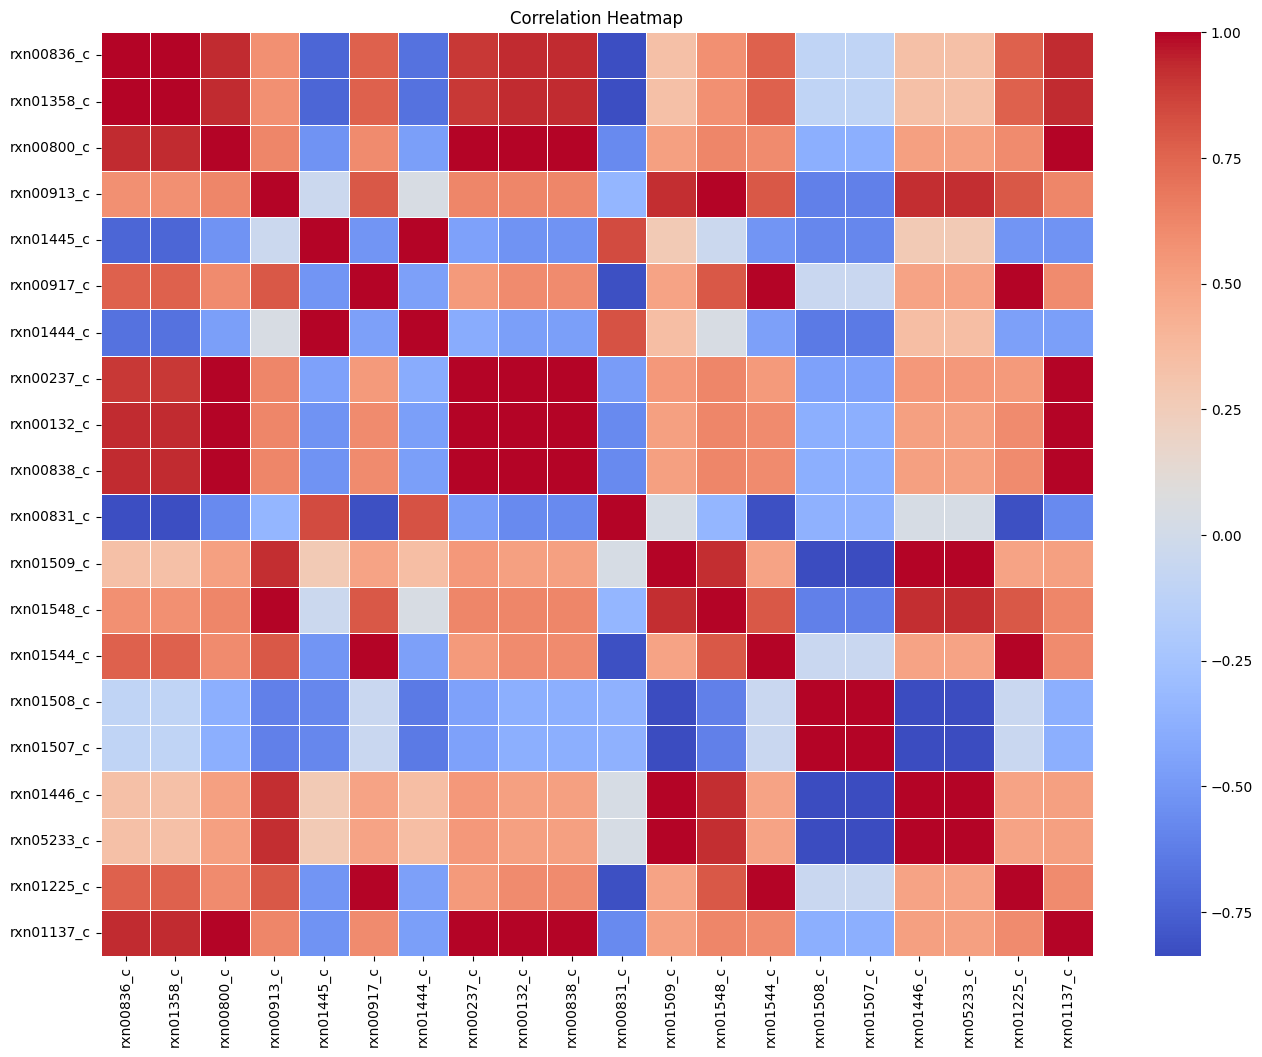

In [289]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix_filter, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [290]:
# Correlation network
nw = cmp.flux_coupling_network(corr_matrix, pc=0.7)
fig = cmp.visualize_interactive_network(nw, mxanthus_normalized_div_by_max, conditions)
fig.show()

Created Flux Coupling network with pc threshold 0.7.
Number of nodes: 180
Number of edges: 2955
Number of connected components: 2


In [291]:
# # Colored pathway network
# nw3 = nw
# cmp.color_network_by_pathway(
#     nw3, pathway= "Purine metabolism", pathway_dict= pathway_dict_M
# )  # takes edge weights into account!

# fig = cmp.visualize_interactive_network(nw3, mxanthus_normalized_div_by_max, conditions)
# fig.show()

In [292]:
# Colored community network
nw2 = nw
cmp.color_network_by_communities(
    nw2, 8, include_weights=True
)  # takes edge weights into account!

comm_map = cmp.get_community_list(nw)
color = cmp.get_color_map(comm_map)

fig = cmp.visualize_interactive_network(nw2, mxanthus_normalized_div_by_max, conditions)
fig.show()

Community map

In [293]:
fig = cmp.community_bar_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [294]:
fig = cmp.community_box_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [295]:
with open("pathway_information/mxanthus_filtered_ids.tsv", "w") as file:
    for line in M_xanthus.reactions:
        file.write(line.id + "\n")

In [296]:
## load ID dictionary (mapping ids to pathways)
filtered_ids = []
with open("pathway_information/mxanthus_filtered_ids.tsv", "r") as file:
    for line in file:
        filtered_ids.append(line.strip())
id_dict = {}
with open("pathway_information/ecoli_map_id_to_pathway.tsv", "r") as file: #TODO REDO THIS FILE FOR MYXO / line correspond to mxanthus_filtered_ids
    for id, line in zip(filtered_ids, file):
        if line == "\n":
            continue
        words = line.strip().split("\t")
        id_dict[id] = words

pathway_hierarchy = {}
with open("pathway_information/kegg_pathway_hierarchy.txt", "r") as file:
    for line in file:
        line = line.rstrip("\n")
        words = line.replace("_", " ").split("\\t")
        pathway_hierarchy[words.pop(0)] = words

In [297]:
# sankey diagram of KEGG pathway categories
fig = cmp.community_sankey_diagram(
    comm_map,
    list(pathway_hierarchy.keys()),
    mxanthus_normalized_div_by_max,
    id_dict,
    diagram_height=1000,
    pw_hierarchy=pathway_hierarchy,
    text_size=16,
)
fig.show()

Look for community 1, 2 and 3

Try also for 7 and 10

In [298]:
for i in comm_map:
    print(i)

#FD3216
#00FE35
#6A76FC
#FED4C4
#FE00CE
#0DF9FF
#F6F926
#FF9616
#479B55
#EEA6FB


In [299]:
# Community 1
Genes_list_1 = []
for i in comm_map["#FD3216"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_1:
            Genes_list_1.append(str(j))

with open('Genes_list_1.txt', 'w') as f:
    for line in Genes_list_1:
        f.write(f"{line}\n")

In [300]:
# Community 2
Genes_list_2 = []
for i in comm_map["#00FE35"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_2:
            Genes_list_2.append(str(j))

with open('Genes_list_2.txt', 'w') as f:
    for line in Genes_list_2:
        f.write(f"{line}\n")

In [301]:
# Community 3
Genes_list_3 = []
for i in comm_map["#6A76FC"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_3:
            Genes_list_3.append(str(j))

with open('Genes_list_3.txt', 'w') as f:
    for line in Genes_list_3:
        f.write(f"{line}\n")

In [302]:
# Community 4
Genes_list_4 = []
for i in comm_map["#FED4C4"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_4:
            Genes_list_4.append(str(j))

with open('Genes_list_4.txt', 'w') as f:
    for line in Genes_list_4:
        f.write(f"{line}\n")

In [303]:
# Community 5
Genes_list_5 = []
for i in comm_map["#FE00CE"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_5:
            Genes_list_5.append(str(j))

with open('Genes_list_5.txt', 'w') as f:
    for line in Genes_list_5:
        f.write(f"{line}\n")

In [314]:
# Community 6
Genes_list_6 = []
for i in comm_map["#F6F926"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_6:
            Genes_list_6.append(str(j))

with open('Genes_list_6.txt', 'w') as f:
    for line in Genes_list_6:
        f.write(f"{line}\n")